In [1]:
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load models and encoders
xgb = joblib.load('../artifacts/xgb_v2.pkl')
rf  = joblib.load('../artifacts/rf_v2.pkl')

# Load feature columns
import json
with open('../artifacts/feature_cols.json') as f:
    feature_cols = json.load(f)

print(f"Feature columns: {feature_cols}")
print(f"\nTotal features: {len(feature_cols)}")
print("✅ Models loaded.")

Feature columns: ['amount_scaled', 'transactions_last_24h', 'card_age_months', 'merchant_enc', 'location_enc', 'time_enc', 'device_enc', 'is_high_risk_location', 'is_late_night', 'is_vpn', 'is_new_device', 'is_high_risk_merchant', 'is_new_card', 'is_high_amount', 'is_micro_transaction', 'is_high_velocity', 'amount_per_card_age', 'velocity_x_amount', 'risk_score']

Total features: 19
✅ Models loaded.


In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Recreate the same dataset for background samples
np.random.seed(42)
N = 100000

merchant_list = ["Groceries","Restaurant","Electronics","Travel","Online transfer","ATM withdrawal","Luxury goods","Crypto exchange"]
location_list = ["Same city","Different state","International","High-risk country"]
time_list     = ["Business hours","Evening","Early morning","Late night (12–5am)"]
device_list   = ["Known device, matching IP","Known device, new IP","New device, matching IP","New device, new IP","VPN / proxy detected"]

def generate_transactions(n):
    data = []
    for i in range(n):
        is_fraud = np.random.random() < 0.015
        if is_fraud:
            amount   = np.random.choice([np.random.uniform(5000,50000), np.random.uniform(0.01,1.00), np.random.uniform(100,500)], p=[0.5,0.3,0.2])
            merchant = np.random.choice(merchant_list, p=[0.05,0.05,0.10,0.05,0.20,0.25,0.10,0.20])
            location = np.random.choice(location_list, p=[0.05,0.20,0.30,0.45])
            time     = np.random.choice(time_list,     p=[0.10,0.20,0.25,0.45])
            tx_24h   = np.random.randint(5, 20)
            card_age = np.random.randint(0, 12)
            device   = np.random.choice(device_list,   p=[0.05,0.15,0.15,0.30,0.35])
        else:
            amount   = np.random.choice([np.random.uniform(5,200), np.random.uniform(200,2000), np.random.uniform(2000,8000)], p=[0.60,0.30,0.10])
            merchant = np.random.choice(merchant_list, p=[0.30,0.25,0.15,0.10,0.08,0.06,0.04,0.02])
            location = np.random.choice(location_list, p=[0.70,0.20,0.08,0.02])
            time     = np.random.choice(time_list,     p=[0.50,0.30,0.12,0.08])
            tx_24h   = np.random.randint(0, 6)
            card_age = np.random.randint(6, 120)
            device   = np.random.choice(device_list,   p=[0.70,0.15,0.08,0.05,0.02])
        data.append({"amount":amount,"merchant_category":merchant,"location":location,"time_of_day":time,"transactions_last_24h":tx_24h,"card_age_months":card_age,"device_match":device,"is_fraud":int(is_fraud)})
    return pd.DataFrame(data)

df = generate_transactions(N)

le_merchant = joblib.load('../artifacts/le_merchant.pkl')
le_location = joblib.load('../artifacts/le_location.pkl')
le_time     = joblib.load('../artifacts/le_time.pkl')
le_device   = joblib.load('../artifacts/le_device.pkl')
scaler      = joblib.load('../artifacts/scaler.pkl')

df_enc = df.copy()
df_enc['merchant_enc']          = le_merchant.transform(df['merchant_category'])
df_enc['location_enc']          = le_location.transform(df['location'])
df_enc['time_enc']              = le_time.transform(df['time_of_day'])
df_enc['device_enc']            = le_device.transform(df['device_match'])
df_enc['amount_scaled']         = scaler.fit_transform(df[['amount']])
df_enc['is_high_risk_location'] = df['location'].isin(['High-risk country','International']).astype(int)
df_enc['is_late_night']         = df['time_of_day'].isin(['Late night (12–5am)','Early morning']).astype(int)
df_enc['is_vpn']                = (df['device_match'] == 'VPN / proxy detected').astype(int)
df_enc['is_new_device']         = df['device_match'].isin(['New device, new IP','New device, matching IP']).astype(int)
df_enc['is_high_risk_merchant'] = df['merchant_category'].isin(['Crypto exchange','ATM withdrawal','Online transfer']).astype(int)
df_enc['is_new_card']           = (df['card_age_months'] < 6).astype(int)
df_enc['is_high_amount']        = (df['amount'] > 5000).astype(int)
df_enc['is_micro_transaction']  = (df['amount'] < 1.0).astype(int)
df_enc['is_high_velocity']      = (df['transactions_last_24h'] > 5).astype(int)
df_enc['amount_per_card_age']   = df['amount'] / (df['card_age_months'] + 1)
df_enc['velocity_x_amount']     = df['transactions_last_24h'] * df['amount']
df_enc['risk_score']            = (
    df_enc['is_high_risk_location'] * 3 + df_enc['is_vpn'] * 3 +
    df_enc['is_late_night'] * 2 + df_enc['is_new_device'] * 2 +
    df_enc['is_high_risk_merchant'] * 2 + df_enc['is_new_card'] * 2 +
    df_enc['is_high_amount'] * 2 + df_enc['is_high_velocity'] * 2 +
    df_enc['is_micro_transaction'] * 2
)

X = df_enc[feature_cols]
y = df_enc['is_fraud']

print(f"Dataset: {X.shape}")
print(f"Fraud rate: {y.mean()*100:.2f}%")
print("✅ Data ready.")

Dataset: (100000, 19)
Fraud rate: 1.53%
✅ Data ready.


In [3]:
# Use 500 background samples for speed
background = shap.sample(X, 500, random_state=42)

print("Computing SHAP values for XGBoost (takes ~1 min)...")
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X.sample(1000, random_state=42))

print(f"SHAP values shape: {shap_values_xgb.shape}")
print("✅ XGBoost SHAP done.")

Computing SHAP values for XGBoost (takes ~1 min)...
SHAP values shape: (1000, 19)
✅ XGBoost SHAP done.


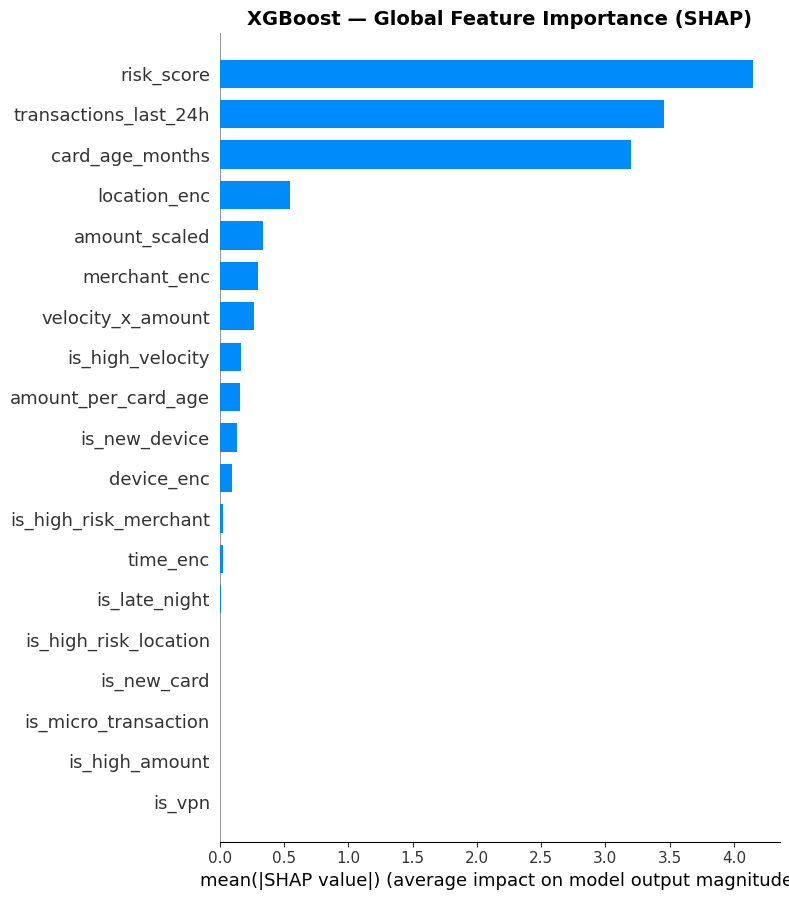

✅ Global SHAP plot saved.


In [4]:
X_sample = X.sample(1000, random_state=42)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_xgb, X_sample,
    feature_names=feature_cols,
    plot_type="bar",
    show=False
)
plt.title("XGBoost — Global Feature Importance (SHAP)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Global SHAP plot saved.")

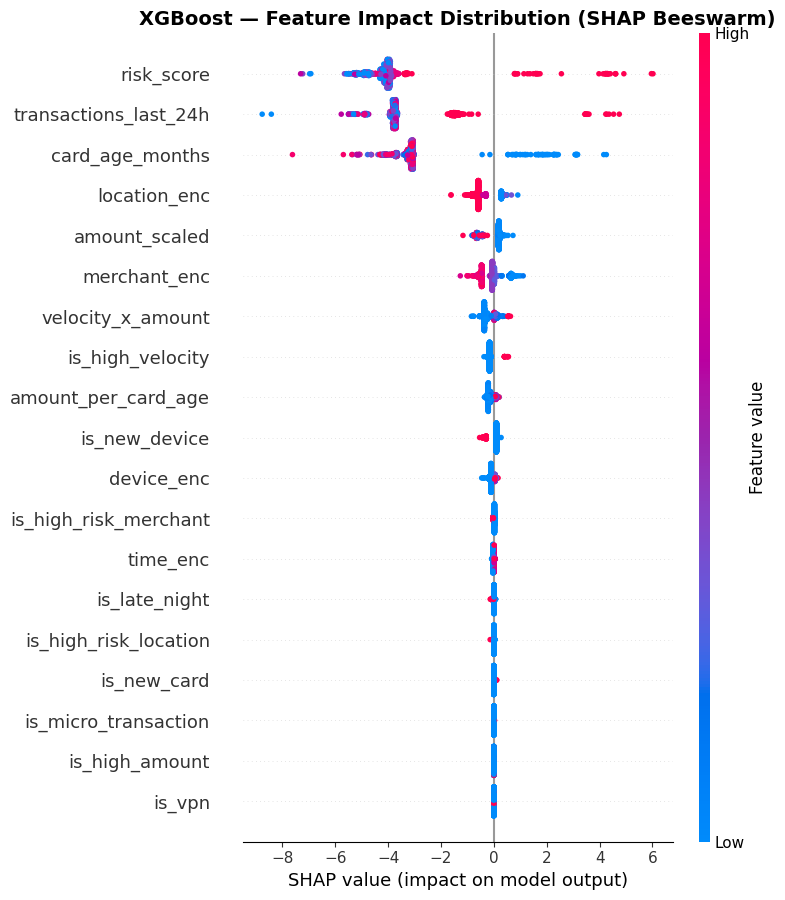

✅ Beeswarm plot saved.


In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_xgb, X_sample,
    feature_names=feature_cols,
    show=False
)
plt.title("XGBoost — Feature Impact Distribution (SHAP Beeswarm)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Beeswarm plot saved.")

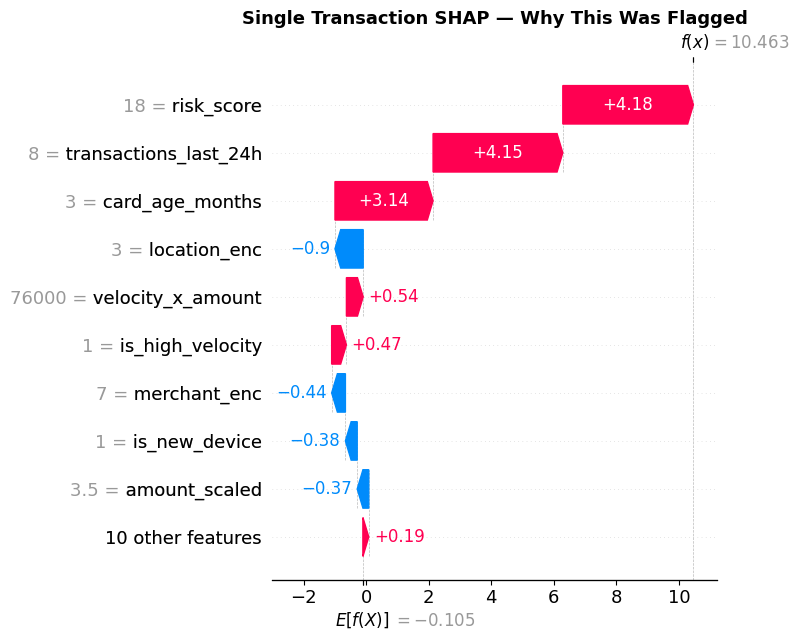


Top contributing features:
  risk_score                     +4.1758  ↑ FRAUD
  transactions_last_24h          +4.1484  ↑ FRAUD
  card_age_months                +3.1364  ↑ FRAUD
  location_enc                   -0.9025  ↓ LEGIT
  velocity_x_amount              +0.5370  ↑ FRAUD
  is_high_velocity               +0.4718  ↑ FRAUD
  merchant_enc                   -0.4398  ↓ LEGIT
  is_new_device                  -0.3772  ↓ LEGIT
✅ Waterfall plot saved.


In [6]:
# Create a high-risk fraud transaction
fraud_tx = pd.DataFrame([{
    'amount_scaled':         3.5,
    'transactions_last_24h': 8,
    'card_age_months':       3,
    'merchant_enc':          7,  # Crypto exchange
    'location_enc':          3,  # High-risk country
    'time_enc':              3,  # Late night
    'device_enc':            4,  # VPN
    'is_high_risk_location': 1,
    'is_late_night':         1,
    'is_vpn':                1,
    'is_new_device':         1,
    'is_high_risk_merchant': 1,
    'is_new_card':           1,
    'is_high_amount':        1,
    'is_micro_transaction':  0,
    'is_high_velocity':      1,
    'amount_per_card_age':   3166.67,
    'velocity_x_amount':     76000,
    'risk_score':            18
}], columns=feature_cols)

shap_single = explainer_xgb.shap_values(fraud_tx)

plt.figure(figsize=(10, 5))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_single[0],
        base_values=explainer_xgb.expected_value,
        data=fraud_tx.iloc[0],
        feature_names=feature_cols
    ),
    show=False
)
plt.title("Single Transaction SHAP — Why This Was Flagged", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../artifacts/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop contributing features:")
contributions = list(zip(feature_cols, shap_single[0]))
contributions.sort(key=lambda x: abs(x[1]), reverse=True)
for feat, val in contributions[:8]:
    direction = "↑ FRAUD" if val > 0 else "↓ LEGIT"
    print(f"  {feat:<30} {val:+.4f}  {direction}")

print("✅ Waterfall plot saved.")

In [7]:
import os

# Save explainer for use in FastAPI
joblib.dump(explainer_xgb, '../artifacts/shap_explainer.pkl')

print("✅ SHAP explainer saved.")
print("\nArtifacts saved:")
for f in sorted(os.listdir('../artifacts')):
    if 'shap' in f:
        print(f"  - {f}")

✅ SHAP explainer saved.

Artifacts saved:
  - shap_beeswarm.png
  - shap_explainer.pkl
  - shap_global.png
  - shap_waterfall.png
